# Supplementary Material S2b – *Glycine max*

## Proteome analysis with N-terminal methionine retention

This notebook documents a reproducible workflow for proteome-level amino acid composition analysis, with particular emphasis on sulfur-containing amino acids (S-AA), methionine (Met, M), and cysteine (Cys, C).

The workflow is implemented using the saa_proteome Python package and is applied here to the *Glycine max* reference proteome as part of the comparative study.

### Workflow overview

- FASTA validation and sequence preprocessing
- Proteome-wide methionine, cysteine, and total S-AA composition
- Localized Met, Cys, and total S-AA enrichment using overlapping windows
- Independent top-protein rankings for each localized metric
- Whole-proteome and individual-protein amino-acid profiles
- Quality-control and descriptive summary tables
- Publication-oriented visualizations and export examples

To reproduce the results, run the notebook cells from top to bottom. Input files are referenced using paths relative to the project root directory. All required input files and paths are specified within the notebook.


## Execution Instructions

Steps:
1. Run the first code cell to install required dependencies
2. Ensure the data files are located in the `data/` directory
3. Run all cells (Kernel → Run All)

Tested with Python 3.9+

In [1]:
# Ensure saa-proteome is installed (installs only if missing)
# type: ignore
try:
    import saa_proteome
except ImportError:
    %pip install git+https://github.com/Hussam-Omari/saa-proteome.git@v0.4.0
    print(
        "saa_proteome was installed from the manuscript release tag. "
        "Restart the kernel and run all cells."
    )

## Software verification and environment check

The following code verifies the analytical environment by importing saa_proteome and reporting the package version used for all analyses

In [2]:
# Software verification and global parameters
# This cell defines all user-controlled inputs in one place to keep the workflow transparent and portable.

from pathlib import Path
import saa_proteome

# Report package version (useful for reproducibility
print("saa_proteome version:", getattr(saa_proteome, "__version__", "unknown"))

saa_proteome version: 0.4.0


## Global analysis parameters and input definition

This section defines all user-controlled inputs and preprocessing options used throughout the notebook. These include the project root directory, input proteome FASTA file, species label, and global analysis parameters such as canonical amino-acid filtering (`CANONICAL_ONLY`), optional N-terminal methionine removal (`REMOVE_START_M`), and sliding-window settings for local methionine enrichment (`WINDOW_SIZE`, `WINDOW_STEP`). Centralizing these parameters ensures methodological transparency, consistent preprocessing across independent and downstream functions, and reproducible propagation of analysis settings throughout the workflow.

> **Primary-analysis setting:** `REMOVE_START_M = False`; therefore, the normalized original protein sequence is retained with its initial methionine, while optional canonical-residue filtering is applied according to the selected analysis settings.

In [3]:
# Define the project root as the directory that contains this notebook.
# If you move the notebook, update PROJECT_ROOT accordingly.
PROJECT_ROOT = Path.cwd()

# Input proteome FASTA file (species-specific dataset used in this analysis)
FASTA_PATH = PROJECT_ROOT / "data" / "UP000008827_3847.fasta"


if not FASTA_PATH.exists():
    raise FileNotFoundError(
        "Input FASTA file was not found. "
        f"Expected location: {FASTA_PATH}. "
        "Run the notebook from the repository root."
    )

print("FASTA_PATH:", FASTA_PATH)


FASTA_PATH: i:\Other computers\My Laptop\Desktop\Proteome_analysis_S_AA\data\UP000008827_3847.fasta


In [4]:
# Define analysis parameters
SPECIES_LABEL = "Glycine max"
SPECIES_CODE = "G_max"

SUPPLEMENT_ID = "S2b"


CANONICAL_ONLY = True    # retain only the 20 standard amino acids; remove non-canonical residues
REMOVE_START_M = False   # keep N-terminal Met when the first residue of a protein sequence is 'M'
WINDOW_SIZE = 100        # sliding-window length (aa) for local enrichment summaries
WINDOW_STEP = 1          # sliding-window step (aa)

CONDITION_LABEL = (
    "remove_start_m_true"
    if REMOVE_START_M
    else "remove_start_m_false"
)

OUTPUT_PREFIX = (
    f"{SUPPLEMENT_ID}_{SPECIES_CODE}_{CONDITION_LABEL}"
)

print("Output prefix:", OUTPUT_PREFIX)


Output prefix: S2b_G_max_remove_start_m_false


## Input proteome data

The workflow is demonstrated using a publicly available proteome FASTA file corresponding to the predicted proteome of the selected crop species. Any proteome-scale FASTA file can be analyzed using the same steps, provided that the file contains standard one-letter amino acid sequences (protein FASTA). To apply the workflow to a different species, replace `FASTA_PATH` and `SPECIES_LABEL` in the parameter cell above.


In [5]:
# Validate the input FASTA file before analysis
from saa_proteome import validate_fasta

validation = validate_fasta(str(FASTA_PATH))

validation


,path,readable,looks_like_fasta,parseable,records_found_probe,first_protein_id,error_message
0,i:\Other computers\My Laptop\Desktop\Proteome_...,True,True,True,1,tr|A0A0R0E6H1|A0A0R0E6H1_SOYBN,None


## Construction of the per-protein proteome metrics dataframe

The `load_proteome_metrics()` function converts the input proteome FASTA file into a per-protein metrics dataframe. 

For each protein sequence, the resulting table reports raw and cleaned sequence lengths, canonical-residue filtering status, N-terminal methionine-removal flags, the final adjusted length after optional N-terminal methionine removal, methionine and cysteine composition percentages, combined sulfur amino-acid content (S-AA = Met + Cys), and maximum localized methionine, cysteine, and combined S-AA enrichment calculated using a sliding-window approach (`WINDOW_SIZE`, `WINDOW_STEP`). The resulting dataframe (`df`) serves as the primary analytical backbone for all downstream quality-control, ranking, composition, and summary analyses.

In [6]:
# Convert the proteome FASTA file to a per-protein metrics dataframe
# The resulting dataframe is the main input for downstream ranking, QC, and summary functions.

from saa_proteome import load_proteome_metrics 

df = load_proteome_metrics(
    fasta_path=str(FASTA_PATH),
    species=SPECIES_LABEL,
    canonical_only=CANONICAL_ONLY,
    remove_start_m=REMOVE_START_M,
    window_size=WINDOW_SIZE,
    window_step=WINDOW_STEP
)

df


,species,protein_id,protein_id_raw,description,aa_count_raw,canonical_only,aa_count_cleaned,remove_start_m,start_m_removed,aa_count_adjusted,...,aa_M_freq,aa_N_freq,aa_P_freq,aa_Q_freq,aa_R_freq,aa_S_freq,aa_T_freq,aa_V_freq,aa_W_freq,aa_Y_freq
0,Glycine max,A0A0R0E6H1,tr|A0A0R0E6H1|A0A0R0E6H1_SOYBN,tr|A0A0R0E6H1|A0A0R0E6H1_SOYBN Uncharacterized...,119,True,119,False,False,119,...,0.016807,0.025210,0.025210,0.033613,0.075630,0.151261,0.067227,0.109244,0.042017,0.008403
1,Glycine max,A0A0R0EHZ9,tr|A0A0R0EHZ9|A0A0R0EHZ9_SOYBN,tr|A0A0R0EHZ9|A0A0R0EHZ9_SOYBN Uncharacterized...,118,True,118,False,False,118,...,0.033898,0.016949,0.008475,0.000000,0.050847,0.118644,0.050847,0.101695,0.033898,0.033898
2,Glycine max,A0A0R0ETG3,tr|A0A0R0ETG3|A0A0R0ETG3_SOYBN,tr|A0A0R0ETG3|A0A0R0ETG3_SOYBN DUF868 domain-c...,306,True,306,False,False,306,...,0.019608,0.039216,0.035948,0.035948,0.032680,0.101307,0.035948,0.098039,0.029412,0.013072
3,Glycine max,A0A0R0EX18,tr|A0A0R0EX18|A0A0R0EX18_SOYBN,tr|A0A0R0EX18|A0A0R0EX18_SOYBN Glutamine amido...,172,True,172,False,False,172,...,0.040698,0.017442,0.093023,0.029070,0.046512,0.087209,0.052326,0.087209,0.011628,0.017442
4,Glycine max,A0A0R0FXY5,tr|A0A0R0FXY5|A0A0R0FXY5_SOYBN,tr|A0A0R0FXY5|A0A0R0FXY5_SOYBN Ricin B lectin ...,263,True,263,False,False,263,...,0.007605,0.079848,0.106464,0.022814,0.041825,0.076046,0.068441,0.068441,0.019011,0.034221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55847,Glycine max,P29136,sp|P29136|MEP1_SOYBN,sp|P29136|MEP1_SOYBN Metalloendoproteinase 1 O...,305,True,305,False,False,305,...,0.016393,0.055738,0.065574,0.026230,0.032787,0.062295,0.088525,0.045902,0.013115,0.052459
55848,Glycine max,P49045,sp|P49045|VPE_SOYBN,sp|P49045|VPE_SOYBN Vacuolar-processing enzyme...,495,True,495,False,False,495,...,0.038384,0.056566,0.044444,0.032323,0.036364,0.074747,0.046465,0.080808,0.016162,0.054545
55849,Glycine max,P86548,sp|P86548|SBTXB_SOYBN,sp|P86548|SBTXB_SOYBN Soybean toxin 17 kDa cha...,25,True,25,False,False,25,...,0.080000,0.040000,0.080000,0.040000,0.040000,0.040000,0.040000,0.080000,0.000000,0.040000
55850,Glycine max,Q2PMS8,sp|Q2PMS8|ATPA_SOYBN,sp|Q2PMS8|ATPA_SOYBN ATP synthase subunit alph...,510,True,510,False,False,510,...,0.021569,0.031373,0.031373,0.070588,0.056863,0.068627,0.058824,0.070588,0.000000,0.035294


## Quality-control (QC) summary

The `qc_report()` generates a quality-control summary to confirm correct proteome parsing and preprocessing. The table reports basic properties of the processed proteome, including protein counts, adjusted sequence length statistics, and the frequency of N-terminal methionine removal. This output is used only for methodological validation.

In [7]:
# Quality-control (QC) summary

from saa_proteome import qc_report

qc = qc_report(df)

qc


,species,total_proteins,mean_length,median_length,min_length,max_length,removed_start_m_pct
0,Glycine max,55852,388.4055,321.0,10,5435,0.0


## Proteome-level summary statistics

The saa_summary() function computes proteome-level summary statistics by aggregating per-protein sulfur amino-acid metrics into species-level descriptors. The function reports the total number of proteins analyzed and calculates mean, median, and selected quantiles (e.g., 50th, 90th, 99th percentiles) for methionine percentage, cysteine percentage, and total sulfur amino-acid content (SAA = Met + Cys). These statistics summarize the global distribution of sulfur-containing amino acids across the proteome.

In [8]:
# Proteome-level summary statistics

from saa_proteome import saa_summary

summary = saa_summary(df)

summary


,species,total_proteins,met_pct_mean,met_pct_median,met_pct_q50,met_pct_q90,met_pct_q99,cys_pct_mean,cys_pct_median,cys_pct_q50,cys_pct_q90,cys_pct_q99,saa_pct_mean,saa_pct_median,saa_pct_q50,saa_pct_q90,saa_pct_q99
0,Glycine max,55852,2.620327,2.417582,2.417582,4.149378,6.896552,2.105247,1.78282,1.78282,3.867403,8.333333,4.725574,4.371585,4.371585,7.21977,12.5


## Protein ranking based on quantitative composition metrics

Proteins can be ranked using the `top_n_proteins()` function according to any numeric metric available in the protein-level dataframe. The selected metric may
represent whole-protein composition, such as `met_pct`, `cys_pct`, or `saa_pct`, or localized enrichment, such as `max_met_per_window`, `max_cys_per_window`, or `max_saa_per_window`. 

The example below ranks proteins by `max_met_per_window`. Users may evaluate other composition metrics by changing only the `metric` argument.

In [9]:
# Example: rank proteins by maximum localized methionine enrichment.
from saa_proteome import top_n_proteins

# Change `metric` to another numeric column, such as
# "max_cys_per_window" or "max_saa_per_window", when required.
max_met_window = top_n_proteins(df,
               metric="max_met_per_window",
               n=5,
               value_scale='pct')
max_met_window

,rank,rank_metric,species,protein_id,description,aa_count_adjusted,met_pct,cys_pct,saa_pct,max_met_per_window,...,aa_M_pct,aa_N_pct,aa_P_pct,aa_Q_pct,aa_R_pct,aa_S_pct,aa_T_pct,aa_V_pct,aa_W_pct,aa_Y_pct
0,1,max_met_per_window,Glycine max,A0A0R0J5A1,tr|A0A0R0J5A1|A0A0R0J5A1_SOYBN FAR1 domain-con...,323,10.835913,2.167183,13.003096,29.0,...,10.835913,6.501548,1.238390,4.024768,4.643963,3.405573,5.572755,6.501548,0.928793,3.095975
1,2,max_met_per_window,Glycine max,K7K3M7,tr|K7K3M7|K7K3M7_SOYBN BHLH domain-containing ...,183,16.393443,0.546448,16.939891,26.0,...,16.393443,6.010929,6.557377,10.382514,3.825137,9.289617,3.278689,4.918033,0.546448,2.185792
2,3,max_met_per_window,Glycine max,I1JKW3,tr|I1JKW3|I1JKW3_SOYBN BHLH transcription fact...,397,7.556675,2.015113,9.571788,24.0,...,7.556675,5.037783,6.045340,7.808564,5.037783,10.579345,7.556675,6.297229,0.755668,2.015113
3,4,max_met_per_window,Glycine max,I1N5E8,tr|I1N5E8|I1N5E8_SOYBN ENTH domain-containing ...,975,3.897436,0.102564,4.000000,22.0,...,3.897436,5.435897,8.410256,7.179487,5.025641,14.051282,5.128205,3.487179,0.512821,3.384615
4,5,max_met_per_window,Glycine max,I1LBE1,tr|I1LBE1|I1LBE1_SOYBN HMA domain-containing p...,560,7.142857,0.535714,7.678571,22.0,...,7.142857,10.357143,5.535714,8.392857,1.428571,3.214286,1.607143,3.214286,0.178571,2.678571


## Top-ranked proteins by sulfur amino acid content

The top_saa_proteins() identifies the top-ranked proteins enriched in sulfur-containing amino acids (methionine + cysteine), based on the precomputed S-AA percentage in the per-protein dataframe. Ranking inherits all preprocessing choices applied during dataframe construction, including N-terminal methionine removal.

In [10]:
# Identify proteins enriched in sulfur-containing amino acids (Met% + Cys%)

from saa_proteome import top_saa_proteins

top_saa = top_saa_proteins(df, n=10, value_scale='pct')

top_saa


,rank,rank_metric,species,protein_id,description,aa_count_adjusted,met_pct,cys_pct,saa_pct,max_met_per_window,max_cys_per_window,max_saa_per_window,start_m_removed
0,1,saa_pct,Glycine max,A0A0R0G5L9,tr|A0A0R0G5L9|A0A0R0G5L9_SOYBN Cysteine-rich t...,56,5.357143,23.214286,28.571429,5.357143,23.214286,28.571429,False
1,2,saa_pct,Glycine max,I1M5N6,tr|I1M5N6|I1M5N6_SOYBN Cysteine-rich transmemb...,56,3.571429,23.214286,26.785714,3.571429,23.214286,26.785714,False
2,3,saa_pct,Glycine max,I1L6B4,tr|I1L6B4|I1L6B4_SOYBN DUF7866 domain-containi...,77,9.090909,15.584416,24.675325,9.090909,15.584416,24.675325,False
3,4,saa_pct,Glycine max,I1JRJ2,tr|I1JRJ2|I1JRJ2_SOYBN Cysteine-rich transmemb...,57,3.508772,21.052632,24.561404,3.508772,21.052632,24.561404,False
4,5,saa_pct,Glycine max,I1MSA0,tr|I1MSA0|I1MSA0_SOYBN Dense and erect pancile...,228,1.754386,22.368421,24.122807,3.000000,38.000000,38.000000,False
5,6,saa_pct,Glycine max,A0A0R0GLP4,tr|A0A0R0GLP4|A0A0R0GLP4_SOYBN G protein gamma...,235,1.702128,22.127660,23.829787,3.000000,38.000000,38.000000,False
6,7,saa_pct,Glycine max,I1K6D3,tr|I1K6D3|I1K6D3_SOYBN Uncharacterized protein...,61,13.114754,9.836066,22.950820,13.114754,9.836066,22.950820,False
7,8,saa_pct,Glycine max,P01064,sp|P01064|IBBD2_SOYBN Bowman-Birk type protein...,83,4.819277,18.072289,22.891566,4.819277,18.072289,22.891566,False
8,9,saa_pct,Glycine max,K7L1G3,tr|K7L1G3|K7L1G3_SOYBN Metallothionein-like pr...,79,5.063291,17.721519,22.784810,5.063291,17.721519,22.784810,False
9,10,saa_pct,Glycine max,P01063,sp|P01063|IBBC2_SOYBN Bowman-Birk type protein...,83,4.819277,16.867470,21.686747,4.819277,16.867470,21.686747,False


## Proteome- and Protein-level amino acid composition

The `aa_composition_df()` function computes canonical amino-acid composition at either the proteome or individual protein level. For each sequence, the output reports residue counts, proportions (0–1), or percentages (0–100) for the 20 canonical amino acids, calculated from sequences processed according to the selected preprocessing parameters (e.g., canonical filtering and optional N-terminal methionine removal). When `extended=True`, the output additionally includes metadata describing preprocessing status and total adjusted residue counts.

In [11]:
# Amino acid composition of the species proteome
from saa_proteome import aa_composition_df

df_aa_proteome = aa_composition_df(
    fasta_path=str(FASTA_PATH),
    species=SPECIES_LABEL,
    level="proteome",          # Proteome-level aggregation
    value_scale="pct",       # {"count", "freq", "pct"}
    canonical_only=CANONICAL_ONLY,
    remove_start_m=REMOVE_START_M,
    extended=True              # Include metadata columns
)

df_aa_proteome

# Note: This function operates directly on the FASTA file rather than reusing the metrics dataframe. 
# This design ensures reproducibility from primary sequence data, avoids dependence on intermediate
# dataframe modifications, and allows the function to be used independently of upstream analysis steps.

,species,level,total_proteins,canonical_only,remove_start_m,proteins_dropped_empty,total_proteins_used,total_aa_adjusted,aa_value_scale,aa_A,...,aa_M,aa_N,aa_P,aa_Q,aa_R,aa_S,aa_T,aa_V,aa_W,aa_Y
0,Glycine max,proteome,55852,True,False,0,55852,21693224,pct,6.46985,...,2.436544,4.769171,4.86144,3.732092,5.08929,8.910981,4.980703,6.526102,1.295764,2.851586


In [12]:
# Amino acid composition at the individual protein level

df_aa_protein = aa_composition_df(
    fasta_path=str(FASTA_PATH),
    species=SPECIES_LABEL,
    level="protein",           # Per-protein composition
    value_scale="count",         # {"count", "freq", "pct"}
    canonical_only=CANONICAL_ONLY,
    remove_start_m=REMOVE_START_M,
    extended=True              # Include metadata columns
)

df_aa_protein.head()

,species,level,protein_id,protein_id_raw,description,canonical_only,aa_count_cleaned,remove_start_m,start_m_removed,aa_count_adjusted,...,aa_M,aa_N,aa_P,aa_Q,aa_R,aa_S,aa_T,aa_V,aa_W,aa_Y
0,Glycine max,protein,A0A0R0E6H1,tr|A0A0R0E6H1|A0A0R0E6H1_SOYBN,tr|A0A0R0E6H1|A0A0R0E6H1_SOYBN Uncharacterized...,True,119,False,False,119,...,2.0,3.0,3.0,4.0,9.0,18.0,8.0,13.0,5.0,1.0
1,Glycine max,protein,A0A0R0EHZ9,tr|A0A0R0EHZ9|A0A0R0EHZ9_SOYBN,tr|A0A0R0EHZ9|A0A0R0EHZ9_SOYBN Uncharacterized...,True,118,False,False,118,...,4.0,2.0,1.0,0.0,6.0,14.0,6.0,12.0,4.0,4.0
2,Glycine max,protein,A0A0R0ETG3,tr|A0A0R0ETG3|A0A0R0ETG3_SOYBN,tr|A0A0R0ETG3|A0A0R0ETG3_SOYBN DUF868 domain-c...,True,306,False,False,306,...,6.0,12.0,11.0,11.0,10.0,31.0,11.0,30.0,9.0,4.0
3,Glycine max,protein,A0A0R0EX18,tr|A0A0R0EX18|A0A0R0EX18_SOYBN,tr|A0A0R0EX18|A0A0R0EX18_SOYBN Glutamine amido...,True,172,False,False,172,...,7.0,3.0,16.0,5.0,8.0,15.0,9.0,15.0,2.0,3.0
4,Glycine max,protein,A0A0R0FXY5,tr|A0A0R0FXY5|A0A0R0FXY5_SOYBN,tr|A0A0R0FXY5|A0A0R0FXY5_SOYBN Ricin B lectin ...,True,263,False,False,263,...,2.0,21.0,28.0,6.0,11.0,20.0,18.0,18.0,5.0,9.0


In [13]:
# Example: Amino acid composition of a single protein

# Top S-AA protein ID
protein_id = str(top_saa.loc[0, "protein_id"])

df_aa_single_protein = aa_composition_df(
    fasta_path=str(FASTA_PATH),
    species=SPECIES_LABEL,
    level="protein",
    value_scale="pct",
    canonical_only=CANONICAL_ONLY,
    remove_start_m=REMOVE_START_M,
    protein_id=protein_id,     # Select a specific protein
    extended=False             # Return only AA composition columns
)

df_aa_single_protein

,protein_id,aa_A,aa_C,aa_D,aa_E,aa_F,aa_G,aa_H,aa_I,aa_K,...,aa_M,aa_N,aa_P,aa_Q,aa_R,aa_S,aa_T,aa_V,aa_W,aa_Y
0,A0A0R0G5L9,5.357143,23.214286,1.785714,8.928571,3.571429,3.571429,1.785714,0.0,1.785714,...,5.357143,0.0,3.571429,7.142857,5.357143,7.142857,5.357143,1.785714,0.0,8.928571


## SAA composition for proteome or protein level

Sulfur amino-acid composition was quantified using `saa_composition_df()`, which derives methionine (Met), cysteine (Cys), and their combined value (SAA = Met + Cys) from canonical amino-acid profiles. Composition can be computed either at the proteome level (aggregated across all proteins) or at the individual protein level. Results may be expressed as absolute counts, proportions (0–1), or percentages (0–100).

In [14]:
# Compute aggregated sulfur amino-acid composition for the entire proteome.
from saa_proteome import saa_composition_df

saa_composition_df(FASTA_PATH, SPECIES_LABEL,
                   level='proteome',
                   value_scale='pct',
                   canonical_only=CANONICAL_ONLY,
                   remove_start_m=REMOVE_START_M,
                   )

,species,level,total_proteins,canonical_only,remove_start_m,proteins_dropped_empty,total_proteins_used,total_aa_adjusted,saa_value_scale,met,cys,saa
0,Glycine max,proteome,55852,True,False,0,55852,21693224,pct,2.436544,1.916981,4.353525


In [15]:
# Compute sulfur amino-acid composition at the individual protein level.
from saa_proteome import saa_composition_df

saa_composition_df(FASTA_PATH, SPECIES_LABEL,
                   level='protein',
                   value_scale='count',
                   canonical_only=CANONICAL_ONLY,
                   remove_start_m=REMOVE_START_M,
                   )

,species,protein_id,description,canonical_only,remove_start_m,start_m_removed,aa_count_cleaned,aa_count_adjusted,saa_value_scale,met,cys,saa
0,Glycine max,A0A0R0E6H1,tr|A0A0R0E6H1|A0A0R0E6H1_SOYBN Uncharacterized...,True,False,False,119,119,count,2.0,4.0,6.0
1,Glycine max,A0A0R0EHZ9,tr|A0A0R0EHZ9|A0A0R0EHZ9_SOYBN Uncharacterized...,True,False,False,118,118,count,4.0,4.0,8.0
2,Glycine max,A0A0R0ETG3,tr|A0A0R0ETG3|A0A0R0ETG3_SOYBN DUF868 domain-c...,True,False,False,306,306,count,6.0,10.0,16.0
3,Glycine max,A0A0R0EX18,tr|A0A0R0EX18|A0A0R0EX18_SOYBN Glutamine amido...,True,False,False,172,172,count,7.0,4.0,11.0
4,Glycine max,A0A0R0FXY5,tr|A0A0R0FXY5|A0A0R0FXY5_SOYBN Ricin B lectin ...,True,False,False,263,263,count,2.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...
55847,Glycine max,P29136,sp|P29136|MEP1_SOYBN Metalloendoproteinase 1 O...,True,False,False,305,305,count,5.0,2.0,7.0
55848,Glycine max,P49045,sp|P49045|VPE_SOYBN Vacuolar-processing enzyme...,True,False,False,495,495,count,19.0,9.0,28.0
55849,Glycine max,P86548,sp|P86548|SBTXB_SOYBN Soybean toxin 17 kDa cha...,True,False,False,25,25,count,2.0,0.0,2.0
55850,Glycine max,Q2PMS8,sp|Q2PMS8|ATPA_SOYBN ATP synthase subunit alph...,True,False,False,510,510,count,11.0,1.0,12.0


## Essential amino acid (EAA) summary

The `eaa_summary()` function computes reference essential-amino-acid (EAA) statistics at the protein level. For each protein, the output reports total EAA count, frequency, and percentage, together with the percentage of the adjusted protein sequence represented by each amino acid included in the selected EAA profile.

In [16]:
# Essential amino acids (EAA) summary

from saa_proteome import eaa_summary

df_eaa = eaa_summary(
    fasta_path=str(FASTA_PATH),
    species=SPECIES_LABEL,
    canonical_only=CANONICAL_ONLY,
    remove_start_m=REMOVE_START_M
)

df_eaa

,species,protein_id,protein_id_raw,description,canonical_only,remove_start_m,eaa_count,eaa_freq,eaa_pct,aa_count_adjusted,...,eaa_profile,eaa_pct_F,eaa_pct_H,eaa_pct_I,eaa_pct_K,eaa_pct_L,eaa_pct_M,eaa_pct_T,eaa_pct_V,eaa_pct_W
0,Glycine max,A0A0R0E6H1,tr|A0A0R0E6H1|A0A0R0E6H1_SOYBN,tr|A0A0R0E6H1|A0A0R0E6H1_SOYBN Uncharacterized...,True,False,56.0,0.470588,47.058824,119,...,human_classic,0.840336,7.563025,1.680672,5.042017,8.403361,1.680672,6.722689,10.924370,4.201681
1,Glycine max,A0A0R0EHZ9,tr|A0A0R0EHZ9|A0A0R0EHZ9_SOYBN,tr|A0A0R0EHZ9|A0A0R0EHZ9_SOYBN Uncharacterized...,True,False,73.0,0.618644,61.864407,118,...,human_classic,17.796610,1.694915,4.237288,3.389831,12.711864,3.389831,5.084746,10.169492,3.389831
2,Glycine max,A0A0R0ETG3,tr|A0A0R0ETG3|A0A0R0ETG3_SOYBN,tr|A0A0R0ETG3|A0A0R0ETG3_SOYBN DUF868 domain-c...,True,False,144.0,0.470588,47.058824,306,...,human_classic,5.882353,2.287582,3.594771,8.169935,8.823529,1.960784,3.594771,9.803922,2.941176
3,Glycine max,A0A0R0EX18,tr|A0A0R0EX18|A0A0R0EX18_SOYBN,tr|A0A0R0EX18|A0A0R0EX18_SOYBN Glutamine amido...,True,False,87.0,0.505814,50.581395,172,...,human_classic,8.720930,2.325581,3.488372,5.813953,11.046512,4.069767,5.232558,8.720930,1.162791
4,Glycine max,A0A0R0FXY5,tr|A0A0R0FXY5|A0A0R0FXY5_SOYBN,tr|A0A0R0FXY5|A0A0R0FXY5_SOYBN Ricin B lectin ...,True,False,109.0,0.414449,41.444867,263,...,human_classic,3.802281,8.365019,3.422053,4.562738,4.942966,0.760456,6.844106,6.844106,1.901141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55847,Glycine max,P29136,sp|P29136|MEP1_SOYBN,sp|P29136|MEP1_SOYBN Metalloendoproteinase 1 O...,True,False,138.0,0.452459,45.245902,305,...,human_classic,5.901639,3.934426,6.229508,5.245902,7.540984,1.639344,8.852459,4.590164,1.311475
55848,Glycine max,P49045,sp|P49045|VPE_SOYBN,sp|P49045|VPE_SOYBN Vacuolar-processing enzyme...,True,False,206.0,0.416162,41.616162,495,...,human_classic,2.424242,3.030303,4.848485,5.858586,7.272727,3.838384,4.646465,8.080808,1.616162
55849,Glycine max,P86548,sp|P86548|SBTXB_SOYBN,sp|P86548|SBTXB_SOYBN Soybean toxin 17 kDa cha...,True,False,10.0,0.400000,40.000000,25,...,human_classic,8.000000,0.000000,8.000000,4.000000,0.000000,8.000000,4.000000,8.000000,0.000000
55850,Glycine max,Q2PMS8,sp|Q2PMS8|ATPA_SOYBN,sp|Q2PMS8|ATPA_SOYBN ATP synthase subunit alph...,True,False,210.0,0.411765,41.176471,510,...,human_classic,2.352941,0.392157,9.215686,4.117647,10.000000,2.156863,5.882353,7.058824,0.000000


## Converting to Publication-Ready Column Labels

The following example demonstrates how internal computational column names can be converted into human-readable labels using `apply_friendly_column_names()` without modifying any numerical results. The internal outputs use stable, machine-readable column names to ensure reproducibility and compatibility across analyses. For manuscript tables and reporting purposes, presentation-ready labels can be applied at the export stage. This conversion affects only column names and does not alter underlying values.

In [17]:
# Example output: Essential amino acids (EAA) summary
df_eaa.head() # previously computed

,species,protein_id,protein_id_raw,description,canonical_only,remove_start_m,eaa_count,eaa_freq,eaa_pct,aa_count_adjusted,...,eaa_profile,eaa_pct_F,eaa_pct_H,eaa_pct_I,eaa_pct_K,eaa_pct_L,eaa_pct_M,eaa_pct_T,eaa_pct_V,eaa_pct_W
0,Glycine max,A0A0R0E6H1,tr|A0A0R0E6H1|A0A0R0E6H1_SOYBN,tr|A0A0R0E6H1|A0A0R0E6H1_SOYBN Uncharacterized...,True,False,56.0,0.470588,47.058824,119,...,human_classic,0.840336,7.563025,1.680672,5.042017,8.403361,1.680672,6.722689,10.924370,4.201681
1,Glycine max,A0A0R0EHZ9,tr|A0A0R0EHZ9|A0A0R0EHZ9_SOYBN,tr|A0A0R0EHZ9|A0A0R0EHZ9_SOYBN Uncharacterized...,True,False,73.0,0.618644,61.864407,118,...,human_classic,17.796610,1.694915,4.237288,3.389831,12.711864,3.389831,5.084746,10.169492,3.389831
2,Glycine max,A0A0R0ETG3,tr|A0A0R0ETG3|A0A0R0ETG3_SOYBN,tr|A0A0R0ETG3|A0A0R0ETG3_SOYBN DUF868 domain-c...,True,False,144.0,0.470588,47.058824,306,...,human_classic,5.882353,2.287582,3.594771,8.169935,8.823529,1.960784,3.594771,9.803922,2.941176
3,Glycine max,A0A0R0EX18,tr|A0A0R0EX18|A0A0R0EX18_SOYBN,tr|A0A0R0EX18|A0A0R0EX18_SOYBN Glutamine amido...,True,False,87.0,0.505814,50.581395,172,...,human_classic,8.720930,2.325581,3.488372,5.813953,11.046512,4.069767,5.232558,8.720930,1.162791
4,Glycine max,A0A0R0FXY5,tr|A0A0R0FXY5|A0A0R0FXY5_SOYBN,tr|A0A0R0FXY5|A0A0R0FXY5_SOYBN Ricin B lectin ...,True,False,109.0,0.414449,41.444867,263,...,human_classic,3.802281,8.365019,3.422053,4.562738,4.942966,0.760456,6.844106,6.844106,1.901141


In [18]:
from saa_proteome import apply_friendly_column_names, eaa_summary

# Convert to publication-ready column names (presentation layer only)
df_eaa_pretty = apply_friendly_column_names(df_eaa)

df_eaa_pretty.head()

,Species,Protein ID,Protein ID (Raw FASTA Token),Protein Description,Canonical Amino Acids Only,Start-Met Removal Enabled,Essential Amino Acid Count,Essential Amino Acid Frequency,Essential Amino Acids (%),Sequence Length (Adjusted),...,Essential Amino Acid Profile,Phenylalanine (%),Histidine (%),Isoleucine (%),Lysine (%),Leucine (%),"Methionine (Essential, %)",Threonine (%),Valine (%),Tryptophan (%)
0,Glycine max,A0A0R0E6H1,tr|A0A0R0E6H1|A0A0R0E6H1_SOYBN,tr|A0A0R0E6H1|A0A0R0E6H1_SOYBN Uncharacterized...,True,False,56.0,0.470588,47.058824,119,...,human_classic,0.840336,7.563025,1.680672,5.042017,8.403361,1.680672,6.722689,10.924370,4.201681
1,Glycine max,A0A0R0EHZ9,tr|A0A0R0EHZ9|A0A0R0EHZ9_SOYBN,tr|A0A0R0EHZ9|A0A0R0EHZ9_SOYBN Uncharacterized...,True,False,73.0,0.618644,61.864407,118,...,human_classic,17.796610,1.694915,4.237288,3.389831,12.711864,3.389831,5.084746,10.169492,3.389831
2,Glycine max,A0A0R0ETG3,tr|A0A0R0ETG3|A0A0R0ETG3_SOYBN,tr|A0A0R0ETG3|A0A0R0ETG3_SOYBN DUF868 domain-c...,True,False,144.0,0.470588,47.058824,306,...,human_classic,5.882353,2.287582,3.594771,8.169935,8.823529,1.960784,3.594771,9.803922,2.941176
3,Glycine max,A0A0R0EX18,tr|A0A0R0EX18|A0A0R0EX18_SOYBN,tr|A0A0R0EX18|A0A0R0EX18_SOYBN Glutamine amido...,True,False,87.0,0.505814,50.581395,172,...,human_classic,8.720930,2.325581,3.488372,5.813953,11.046512,4.069767,5.232558,8.720930,1.162791
4,Glycine max,A0A0R0FXY5,tr|A0A0R0FXY5|A0A0R0FXY5_SOYBN,tr|A0A0R0FXY5|A0A0R0FXY5_SOYBN Ricin B lectin ...,True,False,109.0,0.414449,41.444867,263,...,human_classic,3.802281,8.365019,3.422053,4.562738,4.942966,0.760456,6.844106,6.844106,1.901141


## Export the analysis results

The following example demonstrates how analysis results can be exported to a CSV file using `save_output()`. The code shows how a DataFrame produced by the workflow can be easily saved for external use or reporting.

In [19]:
from saa_proteome import apply_friendly_column_names, save_output

# Optional: Convert to publication-ready column names
df_eaa_pretty = apply_friendly_column_names(df_eaa)

# Export formatted table as a csv file
save_output(
    df_eaa_pretty,
    f"{OUTPUT_PREFIX}_eaa_summary",
    index=False,
)

Output file successfully saved to: S2b_G_max_remove_start_m_false_eaa_summary.csv


## Amino acid frequency heatmap matrix

The `aa_heatmap_matrix() `function computes amino-acid frequency profiles for a selected set of proteins (here, the top SAA-enriched proteins). For each protein, the function recalculates the relative abundance (0–1) of the 20 canonical amino acids directly from the processed FASTA sequences, using the same preprocessing parameters (`CANONICAL_ONLY`, `REMOVE_START_M`). The resulting matrix is used for downstream heatmap visualization and comparative compositional analysis.

In [20]:
# Amino acid composition heatmap matrix

from saa_proteome import aa_heatmap_matrix

heatmap_df = aa_heatmap_matrix(
    df_top=top_saa,
    fasta_path=str(FASTA_PATH),
    canonical_only=CANONICAL_ONLY,
    remove_start_m=REMOVE_START_M
)

heatmap_df

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
A0A0R0G5L9,0.053571,0.232143,0.017857,0.089286,0.035714,0.035714,0.017857,0.000000,0.017857,0.053571,0.053571,0.000000,0.035714,0.071429,0.053571,0.071429,0.053571,0.017857,0.000000,0.089286
I1M5N6,0.035714,0.232143,0.017857,0.053571,0.017857,0.053571,0.035714,0.000000,0.035714,0.071429,0.035714,0.000000,0.035714,0.089286,0.035714,0.071429,0.071429,0.017857,0.000000,0.089286
I1L6B4,0.051948,0.155844,0.000000,0.038961,0.064935,0.090909,0.025974,0.038961,0.051948,0.064935,0.090909,0.051948,0.077922,0.012987,0.038961,0.051948,0.038961,0.038961,0.000000,0.012987
I1JRJ2,0.035088,0.210526,0.000000,0.017544,0.035088,0.175439,0.000000,0.035088,0.000000,0.087719,0.035088,0.017544,0.228070,0.000000,0.000000,0.070175,0.000000,0.017544,0.017544,0.017544
I1MSA0,0.026316,0.223684,0.017544,0.048246,0.030702,0.035088,0.004386,0.017544,0.070175,0.070175,0.017544,0.026316,0.118421,0.008772,0.052632,0.118421,0.052632,0.026316,0.021930,0.013158
A0A0R0GLP4,0.029787,0.221277,0.017021,0.046809,0.029787,0.038298,0.004255,0.017021,0.068085,0.068085,0.017021,0.025532,0.106383,0.012766,0.046809,0.123404,0.068085,0.025532,0.021277,0.012766
I1K6D3,0.016393,0.098361,0.000000,0.032787,0.049180,0.000000,0.049180,0.049180,0.049180,0.098361,0.131148,0.049180,0.016393,0.049180,0.098361,0.081967,0.049180,0.032787,0.000000,0.049180
P01064,0.000000,0.180723,0.132530,0.024096,0.024096,0.012048,0.012048,0.024096,0.060241,0.060241,0.048193,0.024096,0.060241,0.048193,0.060241,0.156627,0.036145,0.000000,0.000000,0.036145
K7L1G3,0.075949,0.177215,0.025316,0.063291,0.012658,0.151899,0.000000,0.000000,0.063291,0.025316,0.050633,0.063291,0.050633,0.012658,0.000000,0.063291,0.088608,0.050633,0.000000,0.025316
P01063,0.048193,0.168675,0.144578,0.036145,0.024096,0.012048,0.036145,0.012048,0.048193,0.060241,0.048193,0.024096,0.060241,0.024096,0.048193,0.144578,0.048193,0.000000,0.000000,0.012048


## Visualization of AA composition heatmap

The following code provides an illustrative example of visualizing amino acid composition of the ten proteins with the highest total S-AA percentages using `plot_aa_heatmap` function. The plot is generated from the amino acid frequency matrix computed earlier and is included solely for exploratory and presentation purposes.

<Axes: xlabel='Amino Acid', ylabel='Protein ID'>

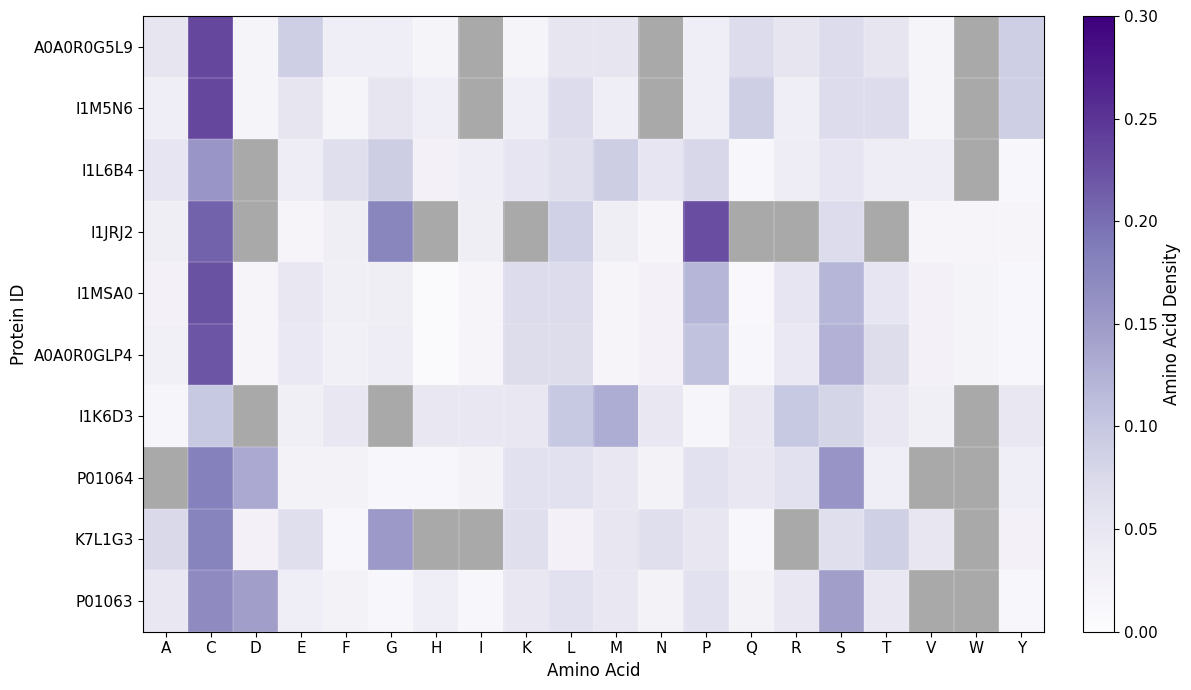

In [21]:
#  Amino acid density heatmap (Default output)
from saa_proteome import plot_aa_heatmap

plot_aa_heatmap(heatmap_df)

# Light shades represent low frequency values approaching zero, while gray boxes indicate complete absence (frequency = 0).

<Axes: title={'center': 'Amino Acid Frequency Heatmap: Glycine max'}, xlabel='Amino Acid', ylabel='Protein ID'>

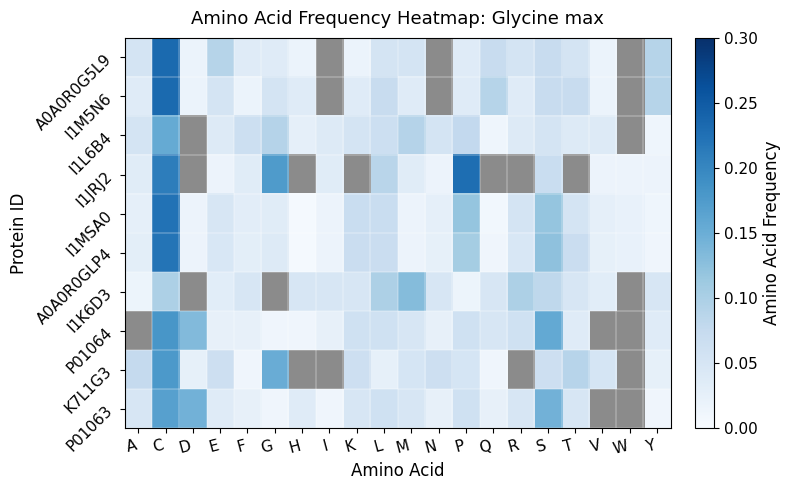

In [22]:
#  Customized Amino acid density heatmap (Fully Parameterized Example)
from saa_proteome import plot_aa_heatmap

# Optional: define absent mask explicitly. 
# This identifies which cells should be treated as “absent” and painted with the overlay color (e.g., dark gray).
absent_mask = heatmap_df.eq(0) # Here, absent means frequency == 0 (default)

plot_aa_heatmap(
    heatmap_df,
    
    # --- Title & axis labels ---
    title=f"Amino Acid Frequency Heatmap: {SPECIES_LABEL}",
    xlabel="Amino Acid",
    ylabel="Protein ID",

    # --- Figure control ---
    figsize=(8, 5),
    font_scale=1,
    # --- Colormap control ---
    cmap="Blues",   # Any valid Matplotlib colormap (e.g., "viridis", "Purples", "Oranges", "magma", "OrRd")
    vmin=0,
    vmax=0.30,        # Fixed scaling for cross-species comparability
    # --- Absent AA overlay ---
    absent_mask=absent_mask,
    absent_color= "#8B8B8B",   # Light gray for absent residues
    # --- Grid styling ---
    linewidths=0.3,
    linecolor="White",
    # --- Colorbar ---
    cbar=True,
    cbar_label="Amino Acid Frequency",
    # --- Tick rotation ---
    xtick_rotation=15,
    ytick_rotation=45,
    xtick_ha="right",
    ytick_ha="right",
    # --- Save plot ---
    save_plot=True,
    save_filename=f"{OUTPUT_PREFIX}_aa_frequency_heatmap" # by default, it saves to the current working directory
)

# Light shades represent low frequency values approaching zero, while gray boxes indicate complete absence (frequency = 0).

## Plotting Barchart for Amino Acid Frequency

### Example 1: Bar plot of top SAA-ranked proteins

In [23]:
# Preview: Top-10 proteins ranked by total sulfur amino acid percentage (SAA = Met% + Cys%)
top_saa.head() # Previously computed

,rank,rank_metric,species,protein_id,description,aa_count_adjusted,met_pct,cys_pct,saa_pct,max_met_per_window,max_cys_per_window,max_saa_per_window,start_m_removed
0,1,saa_pct,Glycine max,A0A0R0G5L9,tr|A0A0R0G5L9|A0A0R0G5L9_SOYBN Cysteine-rich t...,56,5.357143,23.214286,28.571429,5.357143,23.214286,28.571429,False
1,2,saa_pct,Glycine max,I1M5N6,tr|I1M5N6|I1M5N6_SOYBN Cysteine-rich transmemb...,56,3.571429,23.214286,26.785714,3.571429,23.214286,26.785714,False
2,3,saa_pct,Glycine max,I1L6B4,tr|I1L6B4|I1L6B4_SOYBN DUF7866 domain-containi...,77,9.090909,15.584416,24.675325,9.090909,15.584416,24.675325,False
3,4,saa_pct,Glycine max,I1JRJ2,tr|I1JRJ2|I1JRJ2_SOYBN Cysteine-rich transmemb...,57,3.508772,21.052632,24.561404,3.508772,21.052632,24.561404,False
4,5,saa_pct,Glycine max,I1MSA0,tr|I1MSA0|I1MSA0_SOYBN Dense and erect pancile...,228,1.754386,22.368421,24.122807,3.000000,38.000000,38.000000,False


<Axes: title={'center': 'Top 10 SAA-Enriched Proteins - Glycine max'}, xlabel='Protein ID', ylabel='S-AA (%)'>

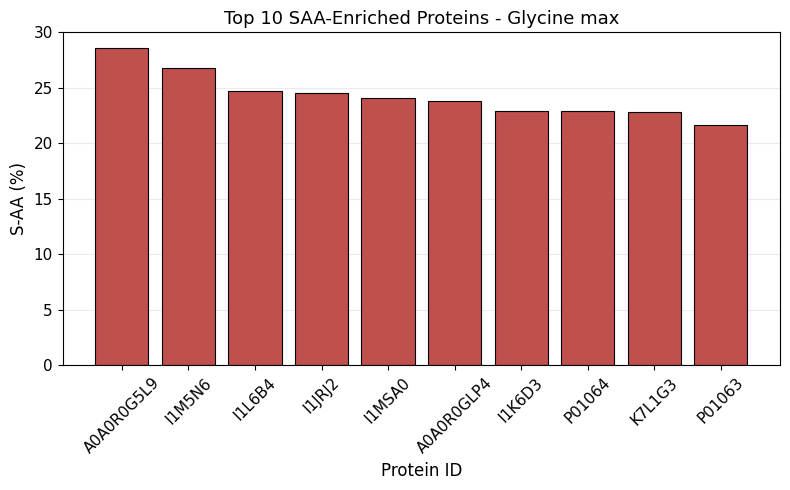

In [24]:
# Bar plot for top S-AA proteins
from saa_proteome import plot_bar

plot_bar(
    df=top_saa,
    x="protein_id",
    y="saa_pct",
    title=f"Top 10 SAA-Enriched Proteins - {SPECIES_LABEL}",
    ylabel="S-AA (%)",
    xlabel="Protein ID",
    xtick_rotation=45,
)

### Example 2: Bar plot for the amino acid composition of the richest-SAA protein

In [25]:
from saa_proteome import aa_profile_table, plot_bar

# Convert wide AA composition (single row) to long format using aa_profile_table function
df_single_long = aa_profile_table(df_aa_single_protein) # Top SAA protein

df_single_long.head()

,AA,Percentage
0,A,5.357143
1,C,23.214286
2,D,1.785714
3,E,8.928571
4,F,3.571429


<Axes: title={'center': 'Amino Acid Composition - A0A0R0G5L9'}, xlabel='Amino Acid', ylabel='Percentage (%)'>

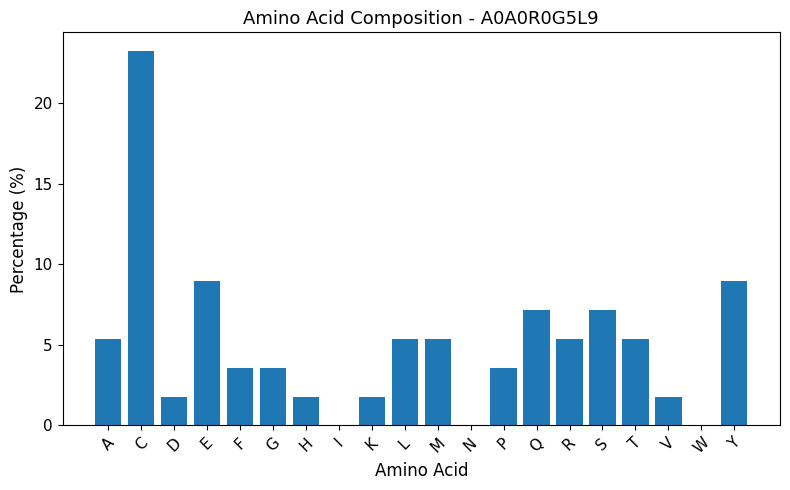

In [26]:
# Plot the AA composition of the highest-SAA protein with some customization
plot_bar(
    df=df_single_long,
    x="AA",
    y="Percentage",
    title=f"Amino Acid Composition - {protein_id}",
    xlabel="Amino Acid",
    ylabel="Percentage (%)",
    xtick_rotation=45,
    grid=False,
    font_scale=1,
    color= 'tab:blue', # Color can also be a single string (e.g., "Red", "tab:orange", '#0f0f0f80') or a list of colors ['red', 'blue', 'orange',...]
    edgecolor= 'None', # Turn Edge color off
)

### Example 3: Bar plot - Window-based methionine enrichment (Top-5 proteins)

This example illustrates visualization of proteins ranked by maximum regional methionine enrichment (`max_met_per_window`). The bar chart displays the top five proteins previously identified using the `top_n_proteins()` function with `metric="max_met_per_window"`.

In [27]:
# DataFrame previously computed. It contains the top-5 proteins ranked by maximum methionine percentage 
# observed within a 100-aa sliding window.

max_met_window

,rank,rank_metric,species,protein_id,description,aa_count_adjusted,met_pct,cys_pct,saa_pct,max_met_per_window,...,aa_M_pct,aa_N_pct,aa_P_pct,aa_Q_pct,aa_R_pct,aa_S_pct,aa_T_pct,aa_V_pct,aa_W_pct,aa_Y_pct
0,1,max_met_per_window,Glycine max,A0A0R0J5A1,tr|A0A0R0J5A1|A0A0R0J5A1_SOYBN FAR1 domain-con...,323,10.835913,2.167183,13.003096,29.0,...,10.835913,6.501548,1.238390,4.024768,4.643963,3.405573,5.572755,6.501548,0.928793,3.095975
1,2,max_met_per_window,Glycine max,K7K3M7,tr|K7K3M7|K7K3M7_SOYBN BHLH domain-containing ...,183,16.393443,0.546448,16.939891,26.0,...,16.393443,6.010929,6.557377,10.382514,3.825137,9.289617,3.278689,4.918033,0.546448,2.185792
2,3,max_met_per_window,Glycine max,I1JKW3,tr|I1JKW3|I1JKW3_SOYBN BHLH transcription fact...,397,7.556675,2.015113,9.571788,24.0,...,7.556675,5.037783,6.045340,7.808564,5.037783,10.579345,7.556675,6.297229,0.755668,2.015113
3,4,max_met_per_window,Glycine max,I1N5E8,tr|I1N5E8|I1N5E8_SOYBN ENTH domain-containing ...,975,3.897436,0.102564,4.000000,22.0,...,3.897436,5.435897,8.410256,7.179487,5.025641,14.051282,5.128205,3.487179,0.512821,3.384615
4,5,max_met_per_window,Glycine max,I1LBE1,tr|I1LBE1|I1LBE1_SOYBN HMA domain-containing p...,560,7.142857,0.535714,7.678571,22.0,...,7.142857,10.357143,5.535714,8.392857,1.428571,3.214286,1.607143,3.214286,0.178571,2.678571


<Axes: title={'center': 'Top-5 proteins ranked by maximum regional methionine enrichment'}, xlabel='Protein ID', ylabel='Max Met per 100 AA (%)'>

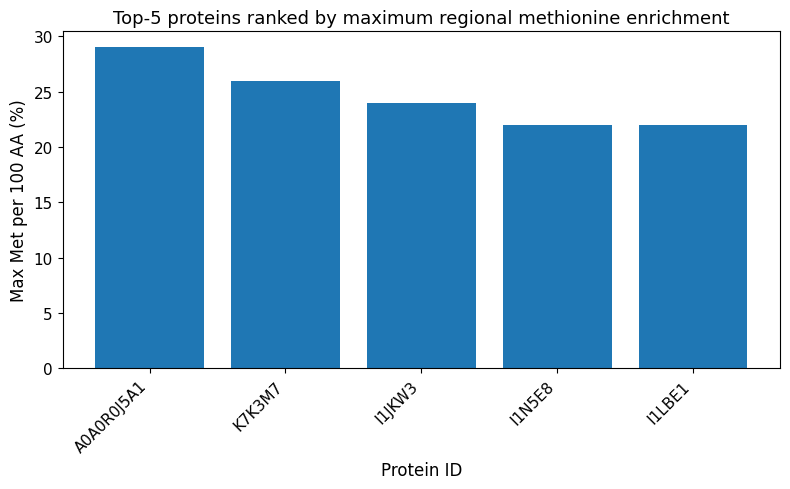

In [28]:
#  Bar plot of top-5 proteins ranked by maximum regional methionine enrichment

from saa_proteome.viz import plot_bar

plot_bar(
    max_met_window,
    x="protein_id",
    y="max_met_per_window",
    title="Top-5 proteins ranked by maximum regional methionine enrichment",
    xlabel="Protein ID",
    ylabel="Max Met per 100 AA (%)",
    font_scale=1.0,
    xtick_rotation=45,
    xtick_ha="right",
    grid=False,
    grid_axis="y",
    color= 'tab:blue', # Color can also be a single string (e.g., "Red", "tab:orange", '#0f0f0f80') or a list of colors ['red', 'blue', 'orange',...]
    edgecolor= 'None', # Turn Edge color off
)

## Data Dictionary (Output Column Definitions)

To enhance transparency and reproducibility, the following table provides a mapping between internal computational column names and their corresponding publication-ready labels. Internal names are used throughout the analytical workflow to ensure consistency and stability of the computational API. Human-readable labels are applied only at the presentation and export stage.

The table below is generated programmatically from the package mapping to ensure that documentation remains synchronized with the codebase.

In [29]:
from saa_proteome import preview_data_dictionary

output_dictionary = preview_data_dictionary()

output_dictionary

,column,label
0,A,Alanine
1,C,Cysteine
2,D,Aspartic Acid
3,E,Glutamic Acid
4,F,Phenylalanine
...,...,...
190,total_proteins,Total Proteins
191,total_proteins_used,Total Proteins Used
192,value_scale,Value Scale
193,window_size,Sliding Window Size (Amino Acids)


In [30]:
# Example: Output label definitions for particular output dataframe
preview_data_dictionary(top_saa)

,column,label
0,rank,Rank
1,rank_metric,Ranking Metric
2,species,Species
3,protein_id,Protein ID
4,description,Protein Description
5,aa_count_adjusted,Sequence Length (Adjusted)
6,met_pct,Methionine (%)
7,cys_pct,Cysteine (%)
8,saa_pct,Total Sulfur Amino Acids (%)
9,max_met_per_window,Maximum Methionine per Sliding Window (%)


## Reproducibility statement

All analyses in this notebook are reproducible using the `saa_proteome` package and the input FASTA file specified in the parameter cell. For transparent provenance, record the repository tag/commit hash used for the analysis in the manuscript or supplement.

## Code availability

Repository (GitHub): https://github.com/Hussam-Omari/saa-proteome  
Release tag used in this supplement: v0.4.0
